<a href="https://colab.research.google.com/github/Thamaraiselvi46/pose_adaptive/blob/main/pose_adaptive_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pose-Confidence-Scheduled Control — Colab runner

Runs the full implementation and evaluation: 36 unit tests, the synthetic
pose-stream dataset, the H1–H3 study, the calibration sweep, the trigger
comparison, and the report generator.

**How to use:** `Runtime → Run all`, then pick `pose_adaptive_control.zip`
when Cell 1 prompts you. A CPU runtime is fine — nothing here uses a GPU.

Roughly 8–12 minutes end to end. This mirrors `RUN.md` step for step, so if a
cell fails you can look up what it was supposed to produce.

## Step 0 — Get the code in and install dependencies

Run the cell and choose `pose_adaptive_control.zip` at the file picker.

*Alternatives:* mount Drive with `from google.colab import drive; drive.mount('/content/drive')`
and unzip from there, or replace this cell with `!git clone <your-repo> pose_adaptive_control`
if you've pushed it.

In [1]:
import os, zipfile

if not os.path.isdir('/content/pose_adaptive_control'):
    from google.colab import files
    up = files.upload()                      # pick pose_adaptive_control.zip
    with zipfile.ZipFile(next(iter(up))) as z:
        z.extractall('/content')

os.chdir('/content/pose_adaptive_control')
os.environ['PYTHONPATH'] = '.'               # needed by tests and trigger_study
print('working dir:', os.getcwd())
print(sorted(os.listdir()))

Saving pose_adaptive_control.zip to pose_adaptive_control.zip
working dir: /content/pose_adaptive_control
['IMPLEMENTATION.md', 'README.md', 'RESULTS.md', 'RUN.md', 'adapters', 'data', 'pose_adaptive', 'requirements.txt', 'results', 'ros_bridge', 'run_all.sh', 'tests']


In [2]:
!pip install -q -r requirements.txt tabulate

import numpy, pandas, scipy, matplotlib, sys
print('python', sys.version.split()[0], '| numpy', numpy.__version__,
      '| pandas', pandas.__version__, '| scipy', scipy.__version__,
      '| matplotlib', matplotlib.__version__)

python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | matplotlib 3.10.0


## Step 1 — Tests first

Four seconds, and worth it: if the SE(3) exp/log round-trip is broken, every
number produced later is meaningless. The suite also asserts the two properties
the paper leans on — that the Eq. (3) update cost doesn't grow from `W = 5` to
`W = 200`, and that a confidence dip shorter than `T_d` doesn't fire the
trigger.

Expected last line: `36/36 passed`.

In [3]:
!PYTHONPATH=. python3 tests/test_core.py

  PASS  test_analytics_latency_fits_inside_the_control_period
  PASS  test_auroc_matches_known_values
  PASS  test_check_clean_config_is_quiet
  PASS  test_check_flags_tau_below_noise_floor
  PASS  test_check_flags_unreachable_trigger
  PASS  test_clear_conditions_give_a_clean_approach
  PASS  test_confidence_floor_matches_alpha_bound
  PASS  test_confidence_saturates_on_clean_stream
  PASS  test_confidence_stays_in_unit_interval
  PASS  test_cp_from_covariance_is_monotone_decreasing
  PASS  test_dataset_replay_is_deterministic
  PASS  test_dataset_sequence_schema_and_roundtrip
  PASS  test_dropouts_drive_confidence_down
  PASS  test_ego_motion_composes_to_identity_when_still
  PASS  test_epl_export_mentions_window_and_threshold
  PASS  test_exp_log_roundtrip
  PASS  test_exp_log_small_angle_branch
  PASS  test_fixed_gain_mode_ignores_confidence
  PASS  test_gain_endpoints_and_monotonicity
  PASS  test_gain_matrix_shape_and_rotation_scaling
  PASS  test_gain_never_leaves_bracket_for_an

## Step 2 — Check the parameter set isn't self-defeating

Validates the two couplings from the paper: `c_th` must sit above `alpha`
(otherwise the trigger is unreachable through the temporal term no matter how
incoherent the stream gets), and `tau` must sit above the estimator's
frame-to-frame noise floor. Expected: `none`.

The second part deliberately breaks both so you can see the check fire.

In [4]:
from pose_adaptive.config import SimConfig

print('default config warnings:', SimConfig().check() or 'none')
print()
for w in SimConfig().with_stream(tau=0.003).with_control(c_th=0.40).check():
    print('WARN:', w, '\n')

default config warnings: none

WARN: c_th (0.4) <= alpha (0.5): since c(t) >= alpha*cp(t), a stream with high per-frame confidence but zero temporal consistency can never trigger Eq. (4). Set c_th > alpha, or lower alpha, if the trigger should respond to temporal incoherence alone. 

WARN: tau (3.0 mm) is below the estimator's frame-to-frame noise floor (~6.8 mm): the consistency indicator will fire on sensor noise under clear conditions. 



## Step 3 — Dataset: generate and evaluate (~2 min)

240 sequences at 30 Hz across four tiers: `clear`, `moderate`, `severe`, and
`sway` — the last being fruit that is fully visible and correctly estimated on
a branch that is moving.

**What to look for:** on the `sway` row, `auroc_c_plan` near 0.84 against
`auroc_cp_plan` near 0.50. Per-frame confidence is blind to a moving target by
construction; only the temporal term sees it. That gap is what the split-trigger
result rests on.

The dataset ships inside the zip, so this reproduces it. To skip generation and
just evaluate the shipped copy, add `--evaluate`.

In [5]:
!python3 -m pose_adaptive.dataset --out data/synthetic_v1

wrote 240 sequences to /content/pose_adaptive_control/data/synthetic_v1
split     test  train  val
tier                      
clear       15     36    9
moderate    15     36    9
severe      15     36    9
sway        15     36    9

median estimate error by tier (mm):
tier
clear       4.90
moderate    5.63
severe      7.50
sway        4.72

dropout rate by tier:
tier
clear       0.014
moderate    0.104
severe      0.241
sway        0.005

=== open-loop evaluation of the Eq. (3) signal ===
AUROC of the confidence signal against two different failures.
  *_est  : the pose estimate is wrong   (what cp is built to catch)
  *_plan : the fruit moved off-plan     (only the temporal term sees it)

[val]
    tier  n_seq  n_frames  pct_est_err  pct_plan_dev  auroc_c_est  auroc_cp_est  auroc_c_plan  auroc_cp_plan  lead_s  trigger_rate
   clear      9       810        3.358        50.864        0.921         0.883         0.603          0.505  -0.333         0.036
moderate      9       810      

## Step 4 — Main study, H1 to H3 (~3 min)

Nine arms on a common seed set. The perception simulator's random draws depend
only on the occlusion protocol and never on controller state, so each seed
reproduces an identical occlusion profile across every arm — which is what
makes the paired Wilcoxon and McNemar tests valid.

Drop to `--trials 50` for a fast pass; every effect keeps its direction and only
the p-values weaken.

In [6]:
TRIALS = 200   # lower to 50 for a quick look

!python3 -m pose_adaptive.experiments --trials {TRIALS} --out results


=== Per-arm summary (200 trials/arm) ===
                         track_var_mean_mm2  track_rms_mean_mm  track_p95_mm  false_approach_rate  missed_rate  commit_pos_err_mm  cycle_time_s  mean_gain  replans  latency_p99_us
arm                                                                                                                                                                                
fixed_Kmin                           51.902             16.720        27.699                0.290        0.000             12.489         2.300      1.000    0.000         170.713
fixed_Kmax                           99.092             15.459        32.279                0.265        0.000             12.244         2.300      8.000    0.000         175.624
adaptive_g0.5                        53.639             13.405        25.663                0.225        0.000             10.537         2.300      6.471    0.000         176.145
adaptive_g1.0                        43.829             12

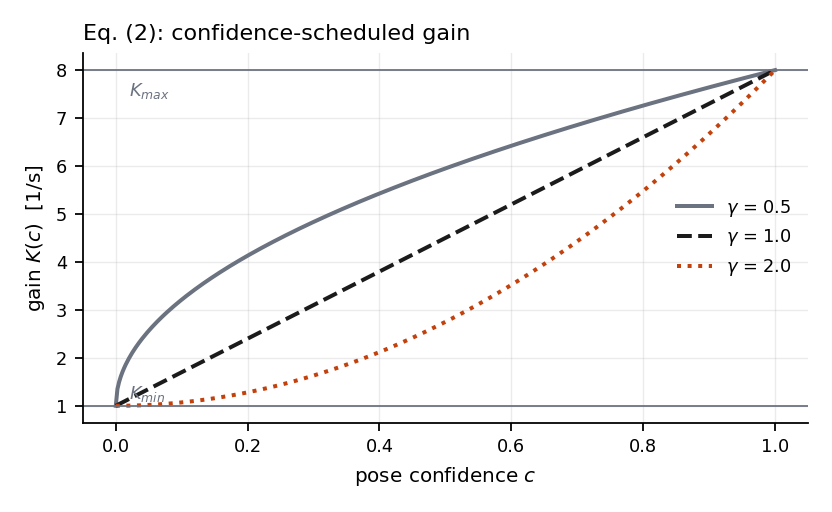

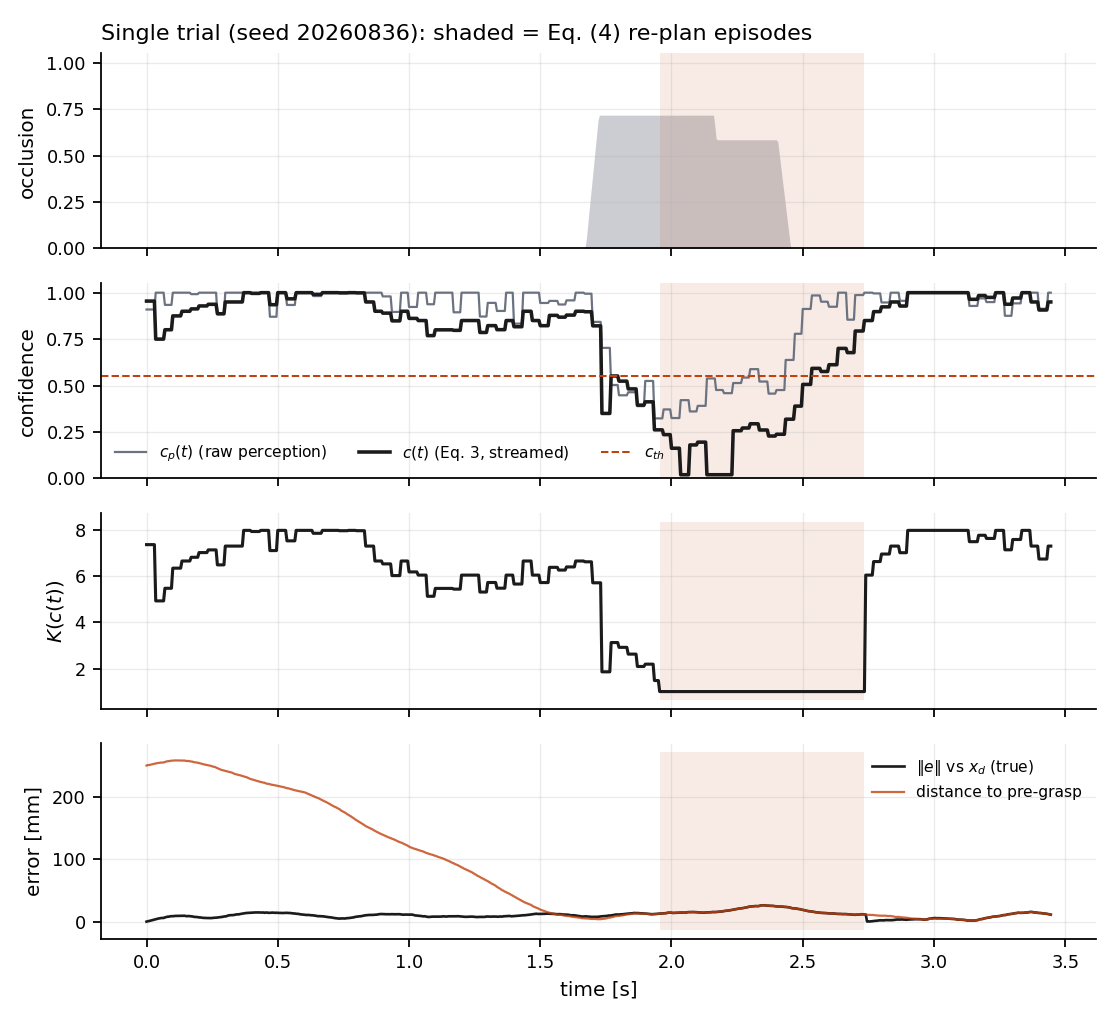

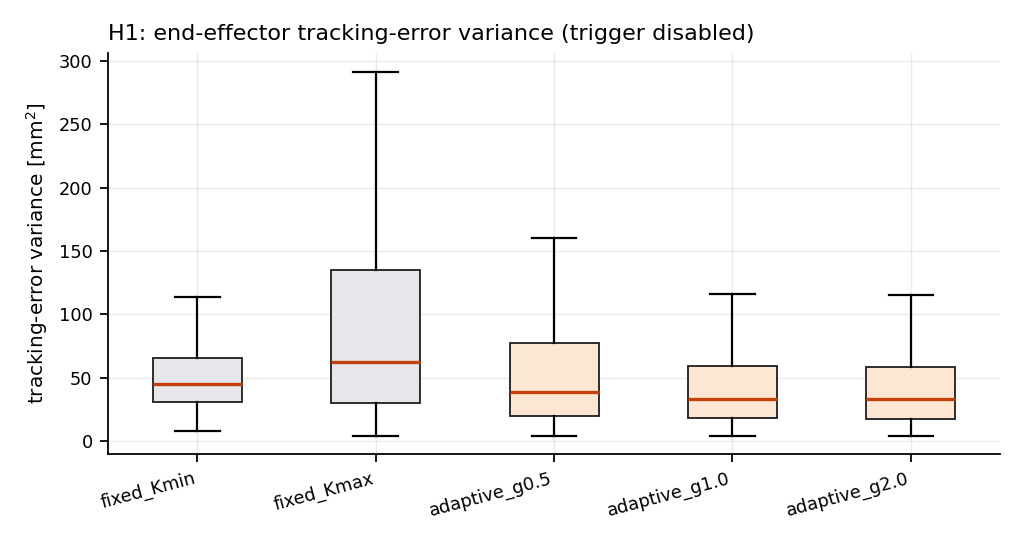

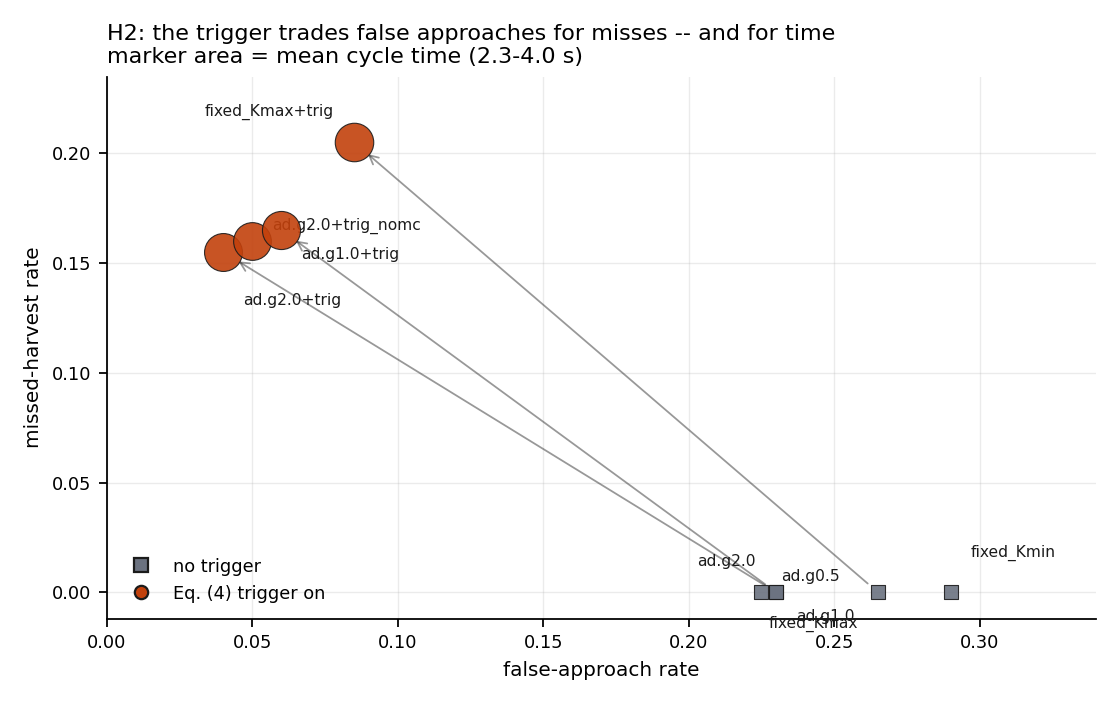

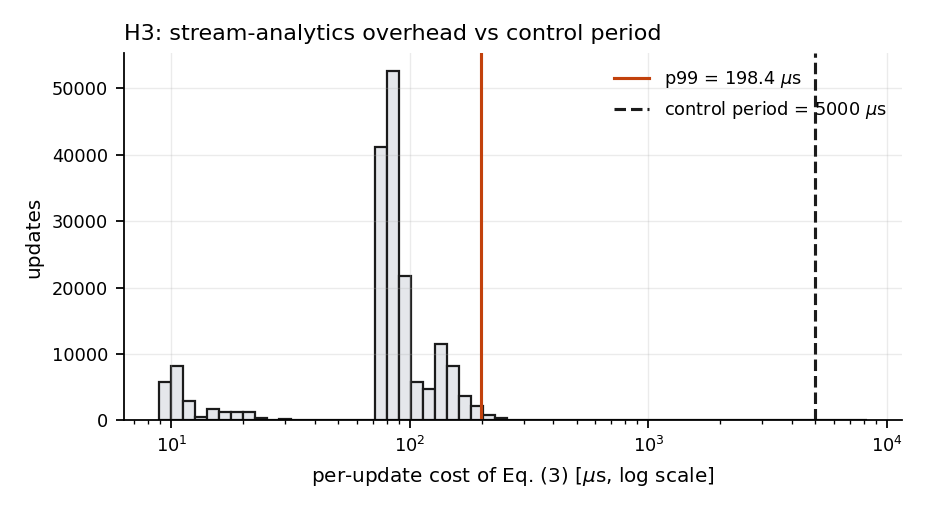

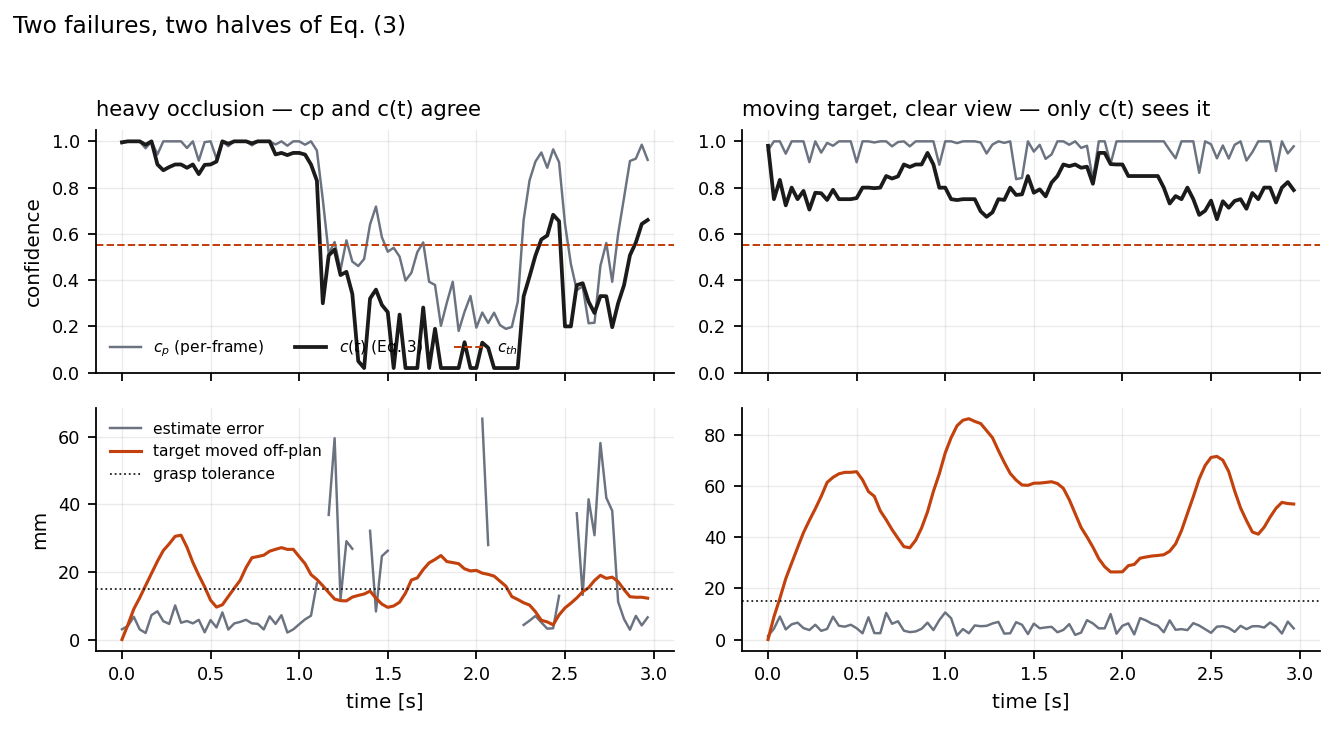

In [7]:
from IPython.display import Image, display

for f in ['fig1_gain_schedule.png', 'fig2_trial_timeline.png',
          'fig3_h1_tracking.png', 'fig4_h2_tradeoff.png',
          'fig5_h3_latency.png', 'fig6_dataset_two_failures.png']:
    display(Image(f'results/{f}'))

## Step 5 — Calibration sweep (~4 min)

Fifty configurations of (gamma, c_th, T_d) ranked by effective throughput, plus
the tau and ego-motion-compensation ablation.

**The fixed-gain baselines top the ranking.** That is the paper's central
negative finding, not a bug — the accuracy gains are real and the time cost is
larger. Watch the tau ablation too: at 8 mm the success rate falls off a cliff,
and the cause is not occlusion but the consistency indicator firing on the
estimator's own noise under clear conditions.

In [8]:
!python3 -m pose_adaptive.sweep --trials 50 --out results


=== Calibration sweep (50 trials per cell, 50 cells) -- ranked by effective throughput ===
          arm  gamma  c_th  dwell  success_rate  false_approach_rate  missed_rate  mean_cycle_s  track_var_mm2  mean_gain  fruit_per_min
   fixed_Kmax    NaN   NaN    NaN         0.740                0.260        0.000         2.300         96.000      8.000         19.304
   fixed_Kmin    NaN   NaN    NaN         0.740                0.260        0.000         2.300         56.998      1.000         19.304
adaptive+trig  2.000 0.300  0.350         0.800                0.200        0.000         2.598         45.495      4.734         18.479
adaptive+trig  1.000 0.300  0.350         0.780                0.220        0.000         2.607         47.297      5.506         17.951
adaptive+trig  0.500 0.300  0.350         0.760                0.240        0.000         2.615         56.880      6.221         17.436
adaptive+trig  3.000 0.300  0.350         0.740                0.260        0.000     

## Step 6 — Scalar vs split trigger (~1 min)

The single-threshold reading of Eq. (4) against the two-threshold amendment,
per tier. Raising the scalar threshold to catch the moving-target failure floods
the clear tier; two thresholds don't.

In [9]:
!PYTHONPATH=. python3 -m pose_adaptive.trigger_study

                   variant  clear_fire  clear_prec  moderate_fire  moderate_prec  severe_fire  severe_prec  sway_fire  sway_prec
          scalar c_th=0.55       0.053       0.521          0.332          0.621        0.528        0.672      0.033      1.000
          scalar c_th=0.78       0.125       0.686          0.464          0.610        0.647        0.670      0.787      0.996
split (c<0.55 | cons<0.55)       0.098       0.689          0.393          0.603        0.602        0.661      0.644      0.995

*_fire = fraction of frames the trigger is active; *_prec = fraction of those frames that were genuinely unsafe


## Step 7 — Regenerate the report

Re-derives every number from the CSVs on disk, including the break-even penalty.
No simulation is re-run, so the write-up cannot drift from the data. Check your
manuscript tables against this output.

In [10]:
!python3 -m pose_adaptive.report --out results --dest RESULTS.md

from IPython.display import Markdown
display(Markdown(open('RESULTS.md').read()))

wrote RESULTS.md (14,253 chars)


# Results

Generated from `results/` by `python3 -m pose_adaptive.report`. 200 trials per arm, common seed set, matched perception input.

> These are simulation results against a synthetic perception error model. They test whether the formulation behaves as hypothesised, not how it performs in a canopy. See README, "Limitations".

## Per-arm summary

| arm                     |   track var (mm²) |   track RMS (mm) |   track p95 (mm) |   false-approach |   missed |   commit err (mm) |   cycle (s) |   mean K |   re-plans |   latency p99 (µs) |
|:------------------------|------------------:|-----------------:|-----------------:|-----------------:|---------:|------------------:|------------:|---------:|-----------:|-------------------:|
| fixed_Kmin              |            51.902 |           16.72  |           27.699 |            0.29  |    0     |            12.489 |       2.3   |    1     |       0    |            170.713 |
| fixed_Kmax              |            99.092 |           15.459 |           32.279 |            0.265 |    0     |            12.244 |       2.3   |    8     |       0    |            175.624 |
| adaptive_g0.5           |            53.639 |           13.405 |           25.663 |            0.225 |    0     |            10.537 |       2.3   |    6.471 |       0    |            176.145 |
| adaptive_g1.0           |            43.829 |           12.973 |           23.591 |            0.23  |    0     |            10.385 |       2.3   |    5.716 |       0    |            172.902 |
| adaptive_g2.0           |            41.078 |           13.073 |           22.963 |            0.23  |    0     |            10.308 |       2.3   |    4.91  |       0    |            172.017 |
| fixed_Kmax+trig         |           103.303 |           16.311 |           32.916 |            0.085 |    0.205 |             8.445 |       4.011 |    5.867 |       2.26 |            170.995 |
| adaptive_g1.0+trig      |            61.621 |           14.048 |           27.122 |            0.06  |    0.165 |             7.816 |       3.971 |    5.097 |       2.19 |            176.127 |
| adaptive_g2.0+trig      |            53.801 |           13.582 |           25.77  |            0.04  |    0.155 |             7.815 |       3.951 |    4.672 |       2.17 |            171.603 |
| adaptive_g2.0+trig_nomc |            52.815 |           13.681 |           25.712 |            0.05  |    0.16  |             8.247 |       3.933 |    4.338 |       2.19 |            164.49  |

`fixed_*` arms use a constant gain; `adaptive_g*` schedule the gain by Eq. (2); `+trig` adds the Eq. (4) dwell trigger; `_nomc` drops ego-motion compensation from the Eq. (3) consistency term.

## H1 — tracking accuracy

*Confidence-scheduled gain vs fixed `K_max`, trigger disabled in both arms so only the gain schedule differs. Paired Wilcoxon.*

| arm           |   var (mm²) |   vs fixed K_max (mm²) | change   |   Wilcoxon p |   n |
|:--------------|------------:|-----------------------:|:---------|-------------:|----:|
| adaptive_g0.5 |       53.64 |                  99.09 | -45.9%   |     1.77e-27 | 200 |
| adaptive_g1.0 |       43.83 |                  99.09 | -55.8%   |     2.52e-25 | 200 |
| adaptive_g2.0 |       41.08 |                  99.09 | -58.5%   |     4.75e-20 | 200 |

**Supported.** Every value of γ tested reduced tracking-error variance against an identically-structured fixed-gain controller under matched perception input.

One caveat the hypothesis does not anticipate: a fixed `K_min` controller also has low tracking variance. Low variance alone does not favour the schedule — what the schedule buys is low variance *together with* the commit accuracy of a high gain, which is visible in the `commit err` column, not in the variance column.

## H2 — false-approach rate

*Dwell-time trigger on vs off, paired McNemar.*

| arm                | false-approach   |   McNemar p | missed        |
|:-------------------|:-----------------|------------:|:--------------|
| fixed_Kmax+trig    | 0.265 → 0.085    |    2.1e-07  | 0.000 → 0.205 |
| adaptive_g1.0+trig | 0.230 → 0.060    |    1.41e-07 | 0.000 → 0.165 |
| adaptive_g2.0+trig | 0.230 → 0.040    |    5.1e-09  | 0.000 → 0.155 |

**Supported on its own terms, but the hypothesis prices the wrong cost.** The trigger reduces false approaches substantially, and the rise in missed harvests is smaller than the fall in false approaches, so H2's qualifier holds. But the dominant cost is neither: it is cycle time, which rises from 2.30 s to 3.95 s. H2 does not mention throughput at all.

## H3 — latency overhead

- updates measured: 177,128
- p50: 82.2 µs, p99: 198.4 µs, max: 8242.1 µs
- control period: 5000 µs
- **p99 = 3.97% of the control period**

**Supported.** The Eq. (3) update is maintained incrementally, so this holds independently of window length `W` — a unit test asserts that the per-update cost does not grow when `W` goes from 5 to 200. Measured under an interpreted runtime on a general-purpose CPU, this bounds the *algorithmic* cost, not the deployed one.

## The finding that matters most: caution has to be priced

The sweep covered 50 configurations of (γ, c_th, T_d). Ranked by effective throughput, `60 · success / cycle`, **the fixed-gain baselines win**:

| arm           |   gamma |   c_th |   dwell |   success_rate |   false_approach_rate |   missed_rate |   mean_cycle_s |   track_var_mm2 |   mean_gain |   fruit_per_min |
|:--------------|--------:|-------:|--------:|---------------:|----------------------:|--------------:|---------------:|----------------:|------------:|----------------:|
| fixed_Kmax    |   nan   |  nan   |  nan    |           0.74 |                  0.26 |             0 |          2.3   |          96     |       8     |          19.304 |
| fixed_Kmin    |   nan   |  nan   |  nan    |           0.74 |                  0.26 |             0 |          2.3   |          56.998 |       1     |          19.304 |
| adaptive+trig |     2   |    0.3 |    0.35 |           0.8  |                  0.2  |             0 |          2.598 |          45.495 |       4.734 |          18.479 |
| adaptive+trig |     1   |    0.3 |    0.35 |           0.78 |                  0.22 |             0 |          2.607 |          47.297 |       5.506 |          17.951 |
| adaptive+trig |     0.5 |    0.3 |    0.35 |           0.76 |                  0.24 |             0 |          2.615 |          56.88  |       6.221 |          17.436 |
| adaptive+trig |     3   |    0.3 |    0.35 |           0.74 |                  0.26 |             0 |          2.554 |          46.14  |       4.285 |          17.384 |
| adaptive+trig |     2   |    0.3 |    0.2  |           0.82 |                  0.18 |             0 |          2.92  |          47.663 |       4.802 |          16.847 |
| adaptive+trig |     3   |    0.3 |    0.2  |           0.8  |                  0.2  |             0 |          2.913 |          47.896 |       4.378 |          16.477 |

The most accurate configuration found (γ=1, c_th=0.3, T_d=0.1) reaches a success rate of 0.860 against 0.740 for `fixed_Kmax` — but takes 3.36 s per cycle against 2.30 s, and loses on throughput.

This is not a verdict against the proposal — it is a statement that the throughput metric charges nothing for a false approach beyond the cycle it consumed, which is plainly wrong for a harvesting arm that has just bruised a fruit or struck a branch. Charging a penalty of *p* seconds per false approach:

> **Break-even at p ≈ 3.7 s.** Below that the aggressive fixed-gain controller wins; above it the cautious pose-adaptive configuration wins.

So the design question is not "does pose-adaptive control help?" but "does a failed approach cost you more than 3.7 seconds of recovery, damaged produce and arm wear?" That is a question a grower can answer and a controller cannot. We recommend H2 be restated in these terms.

## Ablation — τ and ego-motion compensation

*Both are choices Eq. (3) does not determine. Both matter more than γ does.*

| motion_compensated   |   tau_mm |   success_rate |   false_approach_rate |   missed_rate |   mean_cycle_s |   track_var_mm2 |   mean_gain |   fruit_per_min |
|:---------------------|---------:|---------------:|----------------------:|--------------:|---------------:|----------------:|------------:|----------------:|
| True                 |        8 |           0.08 |                  0    |          0.92 |          6.755 |          52.421 |       1.474 |           0.711 |
| True                 |       12 |           0.72 |                  0.04 |          0.24 |          4.928 |          55.362 |       3.464 |           8.766 |
| True                 |       16 |           0.86 |                  0.02 |          0.12 |          4.5   |          59.779 |       4.564 |          11.466 |
| True                 |       20 |           0.84 |                  0.04 |          0.12 |          4.364 |          59.491 |       4.908 |          11.548 |
| True                 |       28 |           0.82 |                  0.06 |          0.12 |          4.167 |          57.856 |       5.058 |          11.807 |
| False                |        8 |           0.02 |                  0    |          0.98 |          6.942 |          52.893 |       1.346 |           0.173 |
| False                |       12 |           0.68 |                  0.06 |          0.26 |          5.074 |          52.85  |       3.055 |           8.041 |
| False                |       16 |           0.82 |                  0.04 |          0.14 |          4.49  |          59.354 |       4.252 |          10.957 |
| False                |       20 |           0.86 |                  0.02 |          0.12 |          4.422 |          59.601 |       4.762 |          11.67  |
| False                |       28 |           0.82 |                  0.06 |          0.12 |          4.165 |          57.947 |       5.055 |          11.812 |

**τ dominates.** At τ = 8 mm the missed-harvest rate is 0.92; at τ = 28 mm it is 0.12. The failure at tight τ is not caused by occlusion at all — it is the consistency indicator firing on the estimator's own frame-to-frame noise under *clear* conditions, de-rating the controller when the scene is easiest. Two clean consecutive estimates differ by ≈ 1.6σ√2 in norm, so τ must sit well above that.

**Ego-motion compensation interacts with τ.** Its benefit is largest at tight τ, where the robot's own ~7 mm of inter-frame motion is comparable to the threshold; at the calibrated τ the two readings of Eq. (3) nearly converge. The practical consequence is that the literal reading of Eq. (3) is not wrong so much as it forces τ upward, which costs sensitivity to genuine perception faults.

## Synthetic dataset — what recorded data can and cannot test

The dataset in `data/synthetic_v1/` is a time-ordered pose stream, which is what Eq. (3) actually consumes. Because it is recorded along a scripted approach it can only evaluate the signal **open-loop** — H1 and H2 still need the simulator. What it does test is the paper's load-bearing assumption: does `c(t)` predict trouble?

Two failures are scored separately, because different halves of Eq. (3) detect them:

- **estimate error** — the reported pose is wrong. `cp` is built for this, and beats `c(t)` on the occluded tiers (AUROC 0.96 vs 0.93 overall): the temporal term can only add lag here.
- **plan deviation** — the pose is right but the fruit moved. `cp` is blind to this by construction. On the `sway` tier `c(t)` reaches AUROC 0.84 while `cp` sits at 0.50, chance.

Neither term dominates. That is the empirical case for Eq. (3) blending two signals — and, below, the case against collapsing them into one threshold.

### The scalar trigger cannot serve both failures

Eq. (3) is a convex blend, so `c(t) ≥ α·cp(t)`. A confident estimator watching a moving target lands near `c = α + (1−α)·consistency ≈ 0.75` at α = 0.5. Catching it needs `c_th > 0.78` — at which point ordinary mild occlusion (`c ≈ 0.70`) fires the trigger continuously.

| variant                    |   clear_fire |   clear_prec |   moderate_fire |   moderate_prec |   severe_fire |   severe_prec |   sway_fire |   sway_prec |
|:---------------------------|-------------:|-------------:|----------------:|----------------:|--------------:|--------------:|------------:|------------:|
| scalar c_th=0.55           |        0.053 |        0.521 |           0.332 |           0.621 |         0.528 |         0.672 |       0.033 |       1     |
| scalar c_th=0.78           |        0.125 |        0.686 |           0.464 |           0.61  |         0.647 |         0.67  |       0.787 |       0.996 |
| split (c<0.55 | cons<0.55) |        0.098 |        0.689 |           0.393 |           0.603 |         0.602 |         0.661 |       0.644 |       0.995 |

`*_fire` is the fraction of frames the trigger is active; `*_prec` the fraction of those that were genuinely unsafe.

Raising the scalar threshold to 0.78 does catch the sway tier (0.04 → 0.70) but doubles firing on clear frames and drops their precision from 0.73 to 0.49. The split trigger — fire on low blended confidence **or** low consistency, each against its own threshold — recovers most of the sway detection (0.62) at 0.04 firing on clear frames and 0.60 precision. **We recommend Eq. (4) be amended to take two thresholds.**

## Figures

| file | shows |
|---|---|
| `fig1_gain_schedule.png` | the K(c) family of Eq. (2) — the paper's unresolved "Figure ??" |
| `fig2_trial_timeline.png` | one trial: occlusion, c_p vs c(t), K(c(t)), trigger episodes, true error |
| `fig3_h1_tracking.png` | H1 — tracking-error variance by arm |
| `fig4_h2_tradeoff.png` | H2 — false-approach vs missed-harvest |
| `fig5_h3_latency.png` | H3 — analytics latency vs control period |
| `fig6_dataset_two_failures.png` | occlusion vs moving-target failure, and which half of Eq. (3) sees each |

`fig2` is the one to read first: it shows the mechanism end to end — occlusion rises, `c_p` sags with perception's own lag, `c(t)` falls faster and further because the consistency term sees the jitter, the gain de-rates, the dwell trigger fires, the arm holds at `K_min`, and the approach resumes once confidence recovers.


## Try your own parameters

Every parameter lives in one frozen dataclass tree, so a variant is one call.
This runs in about 20 seconds.

In [11]:
import numpy as np
from pose_adaptive.config import SimConfig
from pose_adaptive.sim import run_trial

seeds = range(20260820, 20260870)

def score(cfg, label):
    rs = [run_trial(cfg, s) for s in seeds]
    print(f"{label:<26} var {np.mean([r.track_var for r in rs])*1e6:6.1f} mm^2 | "
          f"false {np.mean([r.false_approach for r in rs]):.2f} | "
          f"missed {np.mean([r.missed for r in rs]):.2f} | "
          f"mean K {np.mean([r.mean_gain for r in rs]):.2f}")

base = SimConfig()
score(base.with_control(adaptive=False, use_trigger=False), 'fixed K_max')
score(base.with_control(gamma=2.0),                         'adaptive g=2 + trigger')
score(base.with_control(gamma=2.0).with_stream(tau=0.008),  '... tau = 8 mm')
score(base.with_control(gamma=2.0, use_split_trigger=True), '... split trigger')

fixed K_max                var   96.0 mm^2 | false 0.26 | missed 0.00 | mean K 8.00
adaptive g=2 + trigger     var   59.8 mm^2 | false 0.02 | missed 0.12 | mean K 4.56
... tau = 8 mm             var   52.4 mm^2 | false 0.00 | missed 0.92 | mean K 1.47
... split trigger          var   60.1 mm^2 | false 0.04 | missed 0.26 | mean K 4.25


## Download the results

Colab discards the filesystem when the runtime recycles. Pull anything you want
to keep — the figures in `results/` are the ones that go into the paper.

In [12]:
import shutil
from google.colab import files

shutil.make_archive('/content/results_bundle', 'zip', 'results')
files.download('/content/results_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Three results that look like failures and aren't

**Fixed gain wins on throughput.** The adaptive controller is more accurate and
slower. Break-even is around 3.7 s of unmodelled cost per false approach.

**`cp` out-predicts `c(t)` on estimate error.** The synthetic `cp` shares a
latent variable with the pose error, so it is closer to an oracle than any real
estimator would be. Read the AUROC figures as an upper bound on what Eq. (3) can
achieve, not an estimate of what it will.

**Ego-motion compensation shows no significant effect** at the calibrated tau
(McNemar p = 0.50). It matters at tight tau. Reported as a null result rather
than suppressed.

### What this is

Simulation against a synthetic perception model. It tests whether the formulation
behaves as hypothesised under a controlled error process. It is not evidence
about orchard performance, and absolute rates should be read as comparisons
between arms rather than predictions.